In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df_atletas = pd.read_csv("data/atletas.csv")
df_medallas = pd.read_csv("data/medallas.csv")  

# Reto 4: Edad de entrada y longevidad deportiva
## Descripción
En este reto se analiza la edad de entrada y la longevidad deportiva de los atletas olímpicos, con el objetivo de identificar diferencias estructurales entre los distintos deportes. 
La edad de entrada se define como la edad del atleta en su primera participación olímpica, mientras que la longevidad se mide como el número total de ediciones olímpicas en las que participa. 
El análisis se realiza agregando la información por deporte, utilizando la media como medida representativa, y diferenciando entre Juegos de Verano e Invierno. 

## Tareas del reto
1. Preparar y combinar las tablas de atletas y medallas para identificar la primera participación olímpica de cada atleta.
2. Calcular la edad de entrada y el número de ediciones en las que participa cada atleta.
3. Agregar las métricas de edad de entrada y longevidad a nivel de deporte, utilizando la media como medida representativa y diferenciando entre Juegos de Verano e Invierno.
4. Visualizar la relación entre edad de entrada y longevidad deportiva.
5. Interpretar los resultados y discutir posibles limitaciones del análisis.


## Decisiones importantes en el análisis
- Se utiliza la **media** como medida de agregación debido a la presencia de valores extremos en ambas variables.
- Se analizan **todos los deportes** presentes en el dataset, sin aplicar filtros adicionales.
- La longevidad se mide en ediciones olímpicas y no en años, porque entre unos Juegos y otros siempre pasan varios años, y no todos los atletas pueden competir en todas las ediciones.

## Función de soporte
Para facilitar el análisis, se proporciona la siguiente función que calcula la edad de entrada y la longevidad deportiva de los atletas:
- **Entrada**: DataFrame resultante de la combinación de atletas y medallas.
- **Salida**: DataFrame con una fila por atleta que incluye:
  - edad de entrada
  - número de participaciones olímpicas
- **Descripción**: La función identifica la primera participación olímpica de cada atleta y calcula las métricas asociadas.


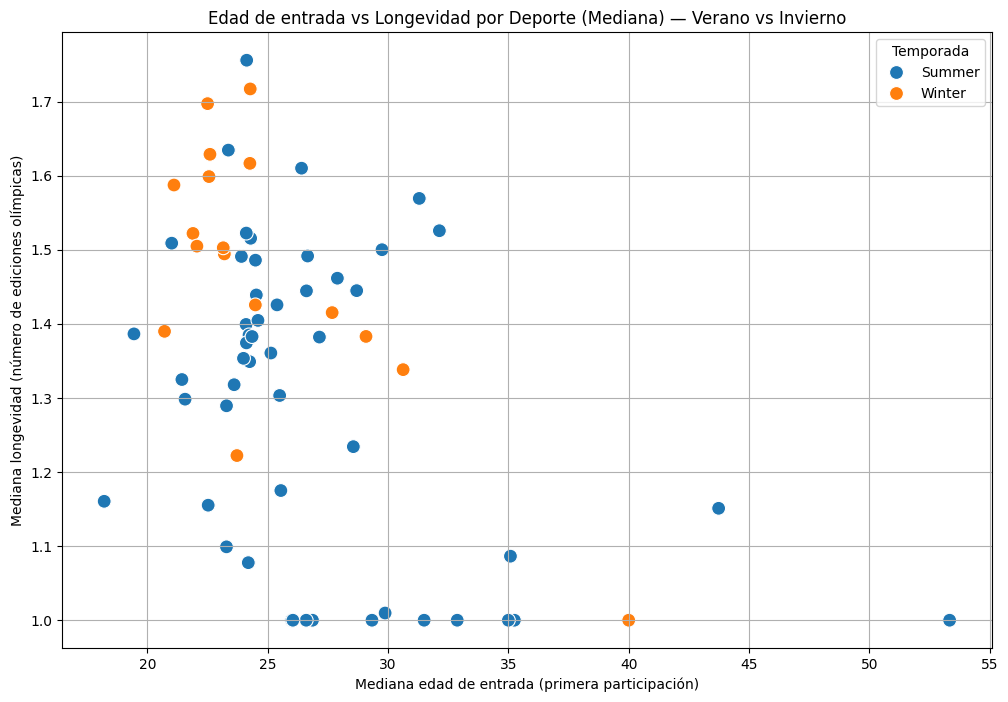

In [ ]:
# Función de soporte
def resumen_carrera_atleta(df_atletas_medallas):
    """
    Devuelve una fila por atleta con:
      - Primer_Año, Primer_Temporada, Primer_Deporte (de la primera participación)
      - Primera_Edad (edad en la primera participación, con imputación si es posible)
      - Numero_de_Participaciones (conteo de ediciones; usa 'Games' si está disponible)
    """
    df_copia = df_atletas_medallas.copy()

    # Definir edades válidas
    mascara_edades_validas = pd.notna(df_copia["Age"]) & (df_copia["Age"] >= 10) & (df_copia["Age"] <= 100)

    # Construir base de atleta desde edades VÁLIDAS:
    #    Ordenar por Año para asegurar que "primero" corresponda al año más temprano.
    df_base = (
        df_copia.loc[mascara_edades_validas]
          .sort_values(["ID", "Year"])
          .groupby("ID", as_index=False)
          .first()[["ID", "Year", "Age"]]
          .rename(columns={"Year": "año_base", "Age": "edad_base"})
    )

    # Adjuntar base a todas las filas
    df_copia = df_copia.merge(df_base, on="ID", how="left")

    # Imputar edades inválidas cuando hay edad base disponible
    mascara_invalida = ~mascara_edades_validas
    se_puede_imputar = mascara_invalida & pd.notna(df_copia["edad_base"]) & pd.notna(df_copia["año_base"])
    df_copia.loc[se_puede_imputar, "Age"] = df_copia.loc[se_puede_imputar, "edad_base"] + (df_copia.loc[se_puede_imputar, "Year"] - df_copia.loc[se_puede_imputar, "año_base"])

    # Determinar fila de primera participación por atleta
    #    Ordenar por Año (y Edad como desempate) para asegurar que "primero" sea correcto
    df_primero = (
        df_copia.sort_values(["ID", "Year", "Age"], na_position="last")
          .groupby("ID", as_index=False)
          .first()
    )

    # Calcular número de ediciones en las que participó
    if "Games" in df_copia.columns and df_copia["Games"].notna().any():
        participaciones = (
            df_copia.groupby("ID")["Games"]
              .nunique()
              .reset_index(name="Numero_de_Participaciones")
        )
    else:
        # alternativa: contar pares únicos (Year, Season) si Games no está disponible
        participaciones = (
            df_copia.dropna(subset=["Year", "Season"])
              .groupby("ID")[["Year", "Season"]]
              .apply(lambda x: x.drop_duplicates().shape[0])
              .reset_index(name="Numero_de_Participaciones")
        )

    # Resultado final: una fila por atleta con contexto de primera participación
    resultado = (
        df_primero[["ID", "Year", "Season", "Sport", "Age"]]
          .rename(columns={
              "Year": "Primer_Año",
              "Season": "Primer_Temporada",
              "Sport": "Primer_Deporte",
              "Age": "Primera_Edad"
          })
          .merge(participaciones, on="ID", how="left")
    )
    
    return resultado


# Tarea 1: Fusionar datasets
df_atletas_medallas = pd.merge(df_atletas, df_medallas, on="ID", how="inner")

# Tarea 2: Resumen de carrera de atleta
df_atletas_inicio_longevidad = resumen_carrera_atleta(df_atletas_medallas)

# Tarea 3: Agregar por deporte + temporada
# IMPORTANTE: Usar Primer_Deporte / Primer_Temporada (consistente con definición de edad de entrada)
df_resumen_deporte_temporada_mediana = (
    df_atletas_inicio_longevidad
      .dropna(subset=["Primera_Edad", "Numero_de_Participaciones", "Primer_Deporte", "Primer_Temporada"])
      .groupby(["Primer_Deporte", "Primer_Temporada"], as_index=False)
      .agg(
          Mediana_Primera_Edad=("Primera_Edad", "median"),
          Mediana_Longevidad=("Numero_de_Participaciones", "median")
      )
      .rename(columns={"Primer_Deporte": "Deporte", "Primer_Temporada": "Temporada"})
)

df_resumen_deporte_temporada_promedio = (
    df_atletas_inicio_longevidad
      .dropna(subset=["Primera_Edad", "Numero_de_Participaciones", "Primer_Deporte", "Primer_Temporada"])
      .groupby(["Primer_Deporte", "Primer_Temporada"], as_index=False)
      .agg(
          Mediana_Primera_Edad=("Primera_Edad", "mean"),
          Mediana_Longevidad=("Numero_de_Participaciones", "mean")
      )
      .rename(columns={"Primer_Deporte": "Deporte", "Primer_Temporada": "Temporada"})
)


# Tarea 4: Visualización (scatter)
plt.figure(figsize=(12, 8))
sns.scatterplot(
    data=df_resumen_deporte_temporada_promedio,
    x="Mediana_Primera_Edad",
    y="Mediana_Longevidad",
    hue="Temporada",
    s=100
)

plt.title("Edad de entrada vs Longevidad por Deporte (Mediana) — Verano vs Invierno")
plt.xlabel("Mediana edad de entrada (primera participación)")
plt.ylabel("Mediana longevidad (número de ediciones olímpicas)")
plt.legend(title="Temporada")
plt.grid(True)
plt.show()

Dado que en la visualización del gráfico se observan patrones interesantes, como la diferencia en longevidad entre deportes de Verano e Invierno, es crucial interpretar estos resultados. 
Ahora vamos a centrarnos en los deportes, mostraremos los deportes con una mayor longevidad deportiva (percentil 90) y con menor longevidad (percentil 10) y al igual que con la edad.

In [8]:
### Seleccionamos los deportes con mayor y menor longevidad deportiva y edad de entrada
# Deportes con mayor longevidad deportiva (percentil 90)
longevidad_90 = df_resumen_deporte_temporada_promedio["Mediana_Longevidad"].quantile(0.9)
deportes_mayor_longevidad = df_resumen_deporte_temporada_promedio[df_resumen_deporte_temporada_promedio["Mediana_Longevidad"] >= longevidad_90]
# Deportes con menor longevidad deportiva (percentil 10)
longevidad_10 = df_resumen_deporte_temporada_promedio["Mediana_Longevidad"].quantile(0.1)
deportes_menor_longevidad = df_resumen_deporte_temporada_promedio[df_resumen_deporte_temporada_promedio["Mediana_Longevidad"] <= longevidad_10]

# Deportes con mayor entrada (percentil 90)
edad_90 = df_resumen_deporte_temporada_promedio["Mediana_Primera_Edad"].quantile(0.9)
deportes_mayor_entrada = df_resumen_deporte_temporada_promedio[df_resumen_deporte_temporada_promedio["Mediana_Primera_Edad"] >= edad_90]

# Deportes con menor entrada (percentil 10)
edad_10 = df_resumen_deporte_temporada_promedio["Mediana_Primera_Edad"].quantile(0.1)
deportes_menor_entrada = df_resumen_deporte_temporada_promedio[df_resumen_deporte_temporada_promedio["Mediana_Primera_Edad"] <= edad_10]

print("Deportes con mayor longevidad deportiva (percentil 90):")
print(deportes_mayor_longevidad)
print("\nDeportes con menor longevidad deportiva (percentil 10):")
print(deportes_menor_longevidad)
print("\nDeportes con mayor edad de entrada (percentil 90):")
print(deportes_mayor_entrada)
print("\nDeportes con menor edad de entrada (percentil 10):")
print(deportes_menor_entrada)


Deportes con mayor longevidad deportiva (percentil 90):
                 Deporte Temporada  Mediana_Primera_Edad  Mediana_Longevidad
12              Biathlon    Winter             24.274674            1.716946
18  Cross Country Skiing    Winter             24.260774            1.616535
23               Fencing    Summer             26.406491            1.610011
37                  Luge    Winter             22.502611            1.697128
56         Speed Skating    Winter             22.601917            1.628754
59          Table Tennis    Summer             24.127517            1.755705
62          Trampolining    Summer             23.365591            1.634409

Deportes con menor longevidad deportiva (percentil 10):
          Deporte Temporada  Mediana_Primera_Edad  Mediana_Longevidad
0     Aeronautics    Summer             26.000000                 1.0
2        Alpinism    Summer             35.250000                 1.0
3        Alpinism    Winter             40.000000            

### Tarea 5: Interpretación de resultados y discusión de limitaciones
Después de completar las tareas anteriores, es importante interpretar los resultados obtenidos y discutir las posibles limitaciones del análisis realizado.
- ¿Qué patrones se observan en la relación entre edad de entrada y longevidad deportiva?
  - Revisando los datos anteriores, podemos ver que los deportes con mayor longevidad (tenis de mesa, esgrima, biatlon) tienden a ser deportes que necesitan más técnica y experiencia, mientras que los deportes con menor longevidad (gimnasia rítmica, patinaje, etc..) suelen requerir más condición física y juventud.
- ¿Existen diferencias significativas entre deportes de Verano e Invierno?
  - En la grafica se puede observar que los deportes de invierno tienden a tener una mayor longevidad deportiva en comparación con los deportes de verano.
- ¿Que posibles limitaciones podrían afectar la validez de los resultados obtenidos?
  - Una limitación importante es que el análisis no considera factores externos como lesiones, cambios en las reglas del deporte o la evolución de la tecnología deportiva, que pueden influir en la longevidad de los atletas.